# Plant Disease Detection from Leaf Images

In [1]:
import os
import shutil
import random

input_path = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

output_path = "/kaggle/working/data"
train_path = os.path.join(output_path, "train")
test_path = os.path.join(output_path, "test")

# Create directories
os.makedirs(train_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)

# Split ratio
split_ratio = 0.8 

# Loop through each class folder
for class_name in os.listdir(input_path):
    class_path = os.path.join(input_path, class_name)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)

    split_index = int(len(images) * split_ratio)

    train_images = images[:split_index]
    test_images = images[split_index:]

    # Create class folders
    os.makedirs(os.path.join(train_path, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_path, class_name), exist_ok=True)

    # Copy train images
    for img in train_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(train_path, class_name, img)
        shutil.copyfile(src, dst)

    # Copy test images
    for img in test_images:
        src = os.path.join(class_path, img)
        dst = os.path.join(test_path, class_name, img)
        shutil.copyfile(src, dst)

print("Dataset split into train and test")

Dataset split into train and test


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

2026-03-18 18:08:47.062918: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773857327.319124     108 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773857327.391493     108 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773857327.962781     108 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773857327.962828     108 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773857327.962831     108 computation_placer.cc:177] computation placer alr

In [3]:
train_dir = "/kaggle/working/data/train"
test_dir = "/kaggle/working/data/test"

## Preprocessing Data

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle= False
)

Found 17699 images belonging to 15 classes.
Found 5003 images belonging to 15 classes.


## Using high accuracy pre-trained model MobileNetV2

In [5]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze layers
for layer in base_model.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

I0000 00:00:1773857356.978260     108 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773857356.984292     108 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Model Compilation

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Added Callbacks & Checkpoints

In [7]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

## Model Training

In [8]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1773857365.674126     183 service.cc:152] XLA service 0x7ee270111c70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773857365.674167     183 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773857365.674172     183 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773857366.763773     183 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-18 18:09:35.166711: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:09:35.322946: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:09:35.459929: E external/local_xl

521/554 ━━━━━━━━━━━━━━━━━━━━ 11s 338ms/step - accuracy: 0.7092 - loss: 0.9377

2026-03-18 18:12:41.252433: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:12:41.395334: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


554/554 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.7151 - loss: 0.9175

2026-03-18 18:13:11.751963: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:13:11.888857: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.87328, saving model to best_model.keras
554/554 ━━━━━━━━━━━━━━━━━━━━ 235s 391ms/step - accuracy: 0.7153 - loss: 0.9169 - val_accuracy: 0.8733 - val_loss: 0.3746
Epoch 2/30
554/554 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.8865 - loss: 0.3419
Epoch 2: val_accuracy improved from 0.87328 to 0.88687, saving model to best_model.keras
554/554 ━━━━━━━━━━━━━━━━━━━━ 190s 343ms/step - accuracy: 0.8865 - loss: 0.3419 - val_accuracy: 0.8869 - val_loss: 0.3232
Epoch 3/30
554/554 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.9012 - loss: 0.2865
Epoch 3: val_accuracy improved from 0.88687 to 0.89586, saving model to best_model.keras
554/554 ━━━━━━━━━━━━━━━━━━━━ 187s 338ms/step - accuracy: 0.9012 - loss: 0.2865 - val_accuracy: 0.8959 - val_loss: 0.2994
Epoch 4/30
554/554 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.9135 - loss: 0.2590
Epoch 4: val_accuracy improved from 0.89586 to 0.91205, saving model to best_model.keras
554/554 ━━━━━━━━━━━

## Accuracy & Loss Graphs

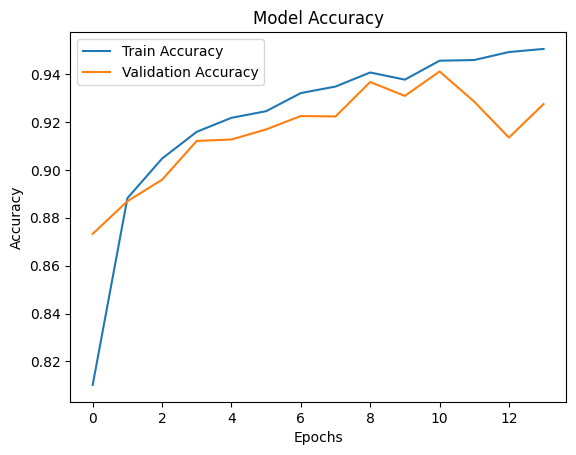

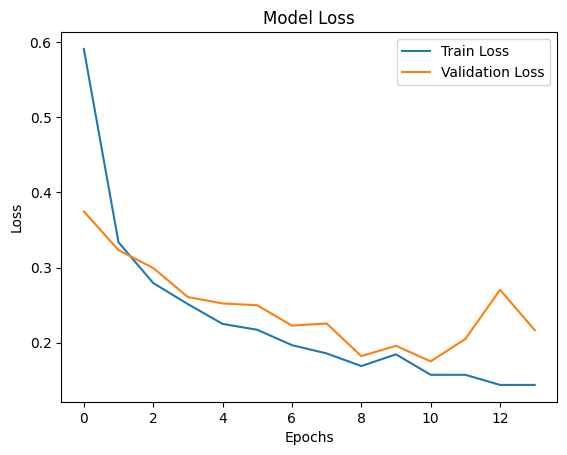

In [9]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Predictions

In [10]:
import numpy as np

# Reset generator
test_data.reset()

# Predict
pred_probs = model.predict(test_data, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_data.classes
class_names = list(test_data.class_indices.keys())

157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step


## Confusion Matrix

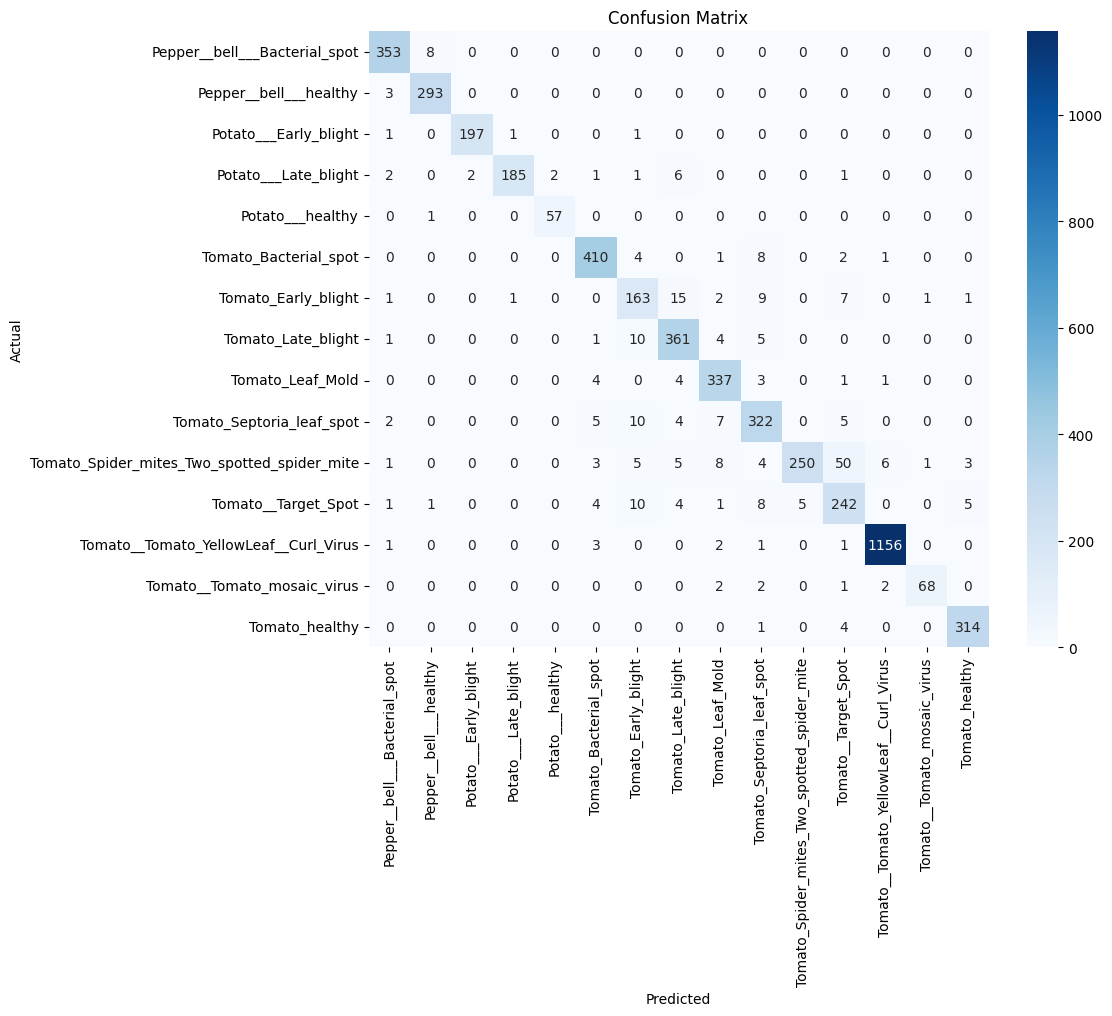

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Classification Report

In [12]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.96      0.98      0.97       361
                     Pepper__bell___healthy       0.97      0.99      0.98       296
                      Potato___Early_blight       0.99      0.98      0.99       200
                       Potato___Late_blight       0.99      0.93      0.96       200
                           Potato___healthy       0.97      0.98      0.97        58
                      Tomato_Bacterial_spot       0.95      0.96      0.96       426
                        Tomato_Early_blight       0.80      0.81      0.81       200
                         Tomato_Late_blight       0.90      0.95      0.92       382
                           Tomato_Leaf_Mold       0.93      0.96      0.94       350
                  Tomato_Septoria_leaf_spot       0.89      0.91      0.90       355
Tomato_Spider_mites_Two_spotted_spider_mite       0.98      0.74

## F1 score

In [13]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred, average='weighted')
print("Overall F1 Score:", f1)

Overall F1 Score: 0.9407451706562381


## Precision & Recall

In [14]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.9432073666090848
Recall: 0.9410353787727364


## ROC Curve

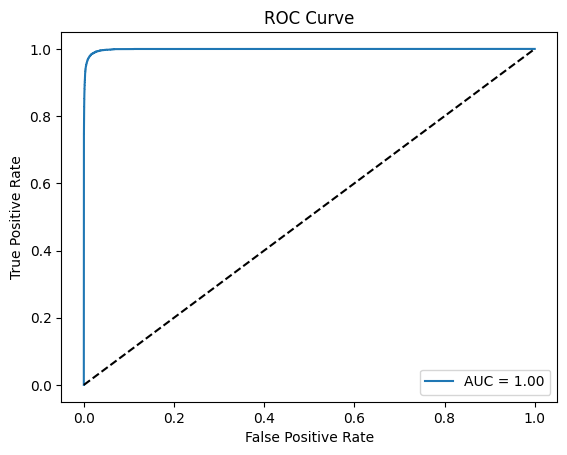

In [15]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(y_true, classes=range(len(class_names)))

fpr, tpr, _ = roc_curve(y_true_bin.ravel(), pred_probs.ravel())
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Save Model

In [16]:
model.save("plant_model.keras")

## Testing On a Random Single Image from Test Folder

2026-03-18 18:54:08.621640: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 18:54:08.754902: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


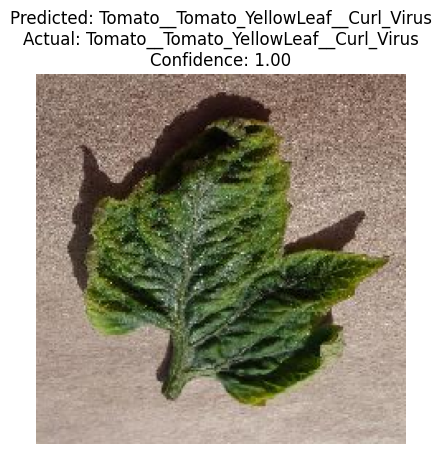

Image Path: /kaggle/working/data/test/Tomato__Tomato_YellowLeaf__Curl_Virus/099b0332-14bf-4866-8c3b-e753e7e62105___YLCV_NREC 2398.JPG
Actual Class: Tomato__Tomato_YellowLeaf__Curl_Virus
Predicted Class: Tomato__Tomato_YellowLeaf__Curl_Virus
Confidence: 0.9998
Correct Prediction


In [17]:
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Pick random image
img_path = random.choice(test_data.filepaths)

# Extract actual class
true_class = img_path.split("/")[-2]

# Load and preprocess image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)

class_names = list(train_data.class_indices.keys())
pred_index = np.argmax(pred)
pred_class = class_names[pred_index]
confidence = pred[0][pred_index]

# Show image with prediction
plt.imshow(img)
plt.title(f"Predicted: {pred_class}\nActual: {true_class}\nConfidence: {confidence:.2f}")
plt.axis('off')
plt.show()

# Print results
print("Image Path:", img_path)
print("Actual Class:", true_class)
print("Predicted Class:", pred_class)
print("Confidence:", round(float(confidence), 4))

# Check correctness
if pred_class == true_class:
    print("Correct Prediction")
else:
    print("Wrong Prediction")